In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from matplotlib.colors import ListedColormap
import seaborn as sns
import matplotlib.pyplot as plt

bids_folder = "/mnt_03/ds-smile1/" 
source_folder = op.join(bids_folder,'derivatives','correlation_matrices')

subList = [int(f[4:]) for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 7]

In [ ]:
# get average CM 
group = 'All'
ses=1
task='rest'
number_of_vertices = 20484
av_cm = np.zeros((number_of_vertices, number_of_vertices))
N_subs = len(subList)

for sub in subList:
    cm_file = op.join(source_folder, f'sub-{sub}_ses-{ses}_task-{task}_CM-unfiltered.npy')
    try:
        cm = np.load(cm_file)
        av_cm += np.arctan(cm)
    except:
        print(f'sub-{sub} missing') 
        N_subs -= 1
    
av_cm = av_cm/N_subs
av_cm_transf = np.tan(av_cm) # sanity check: diagonal should be 1 !

np.save(op.join(source_folder,f'average-{group}_Nsubs-{N_subs}_ses-{ses}_task-{task}_CM-unfiltered.npy'), av_cm_transf)

sub-201 missing
sub-311 missing
sub-303 missing
sub-102 missing
sub-103 missing
sub-203 missing
sub-105 missing
sub-205 missing
sub-104 missing
sub-204 missing
sub-307 missing
sub-310 missing


In [7]:
target_dir = op.join(bids_folder,'derivatives','gradients',f'sub-{group}')

from brainspace.gradient import GradientMaps

av_cm_transf = op.join(source_folder,f'average-{group}_Nsubs-{N_subs}_ses-{ses}_task-{task}_CM-unfiltered.npy')

gm = GradientMaps(n_components=n_components) # defaults: approacch = 'dm', kernel = None
gm.fit(av_cm_transf)

np.save(op.join(target_dir,f'average-{group}_Nsubs-{N_subs}_ses-{ses}_task-{task}_gradients.npy'), gm.gradients_) # save all together
np.save(op.join(target_dir,f'average-{group}_Nsubs-{N_subs}_ses-{ses}_task-{task}_lambdas.npy'), gm.lambdas_) # save all together



## Visualize

In [2]:
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import seaborn as sns
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'viridis'
n_comp = 5


In [7]:
grad.shape

(18715, 10)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


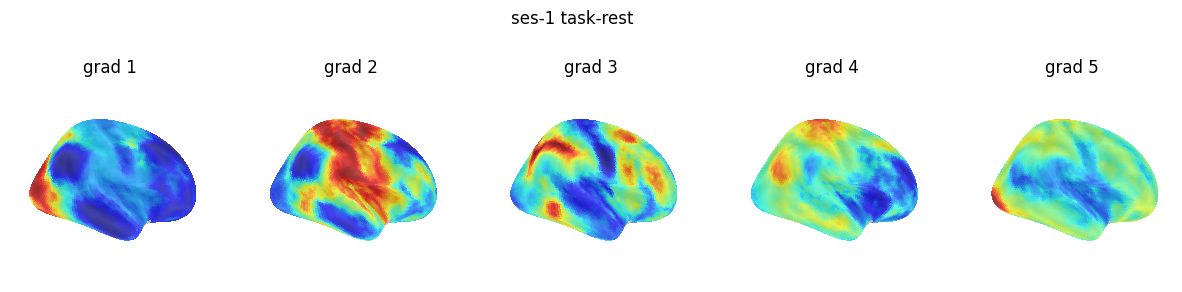

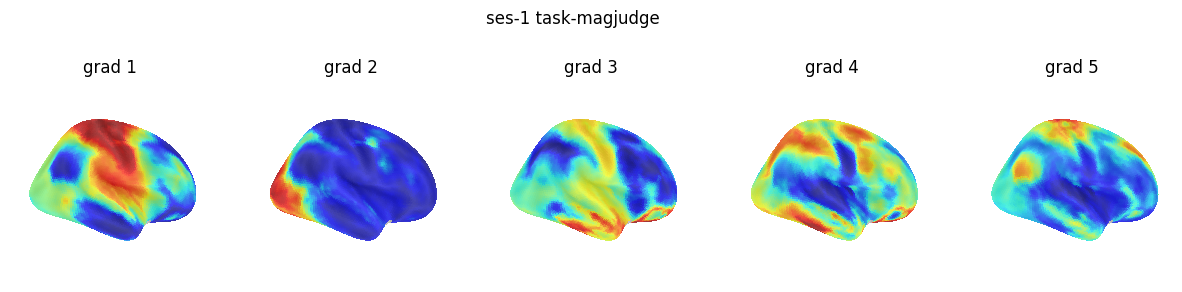

In [23]:
from brainspace.utils.parcellation import map_to_labels
from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

tasks = ['rest', 'magjudge']
group = 'All'
ses = 1
n_comp = 5
N_subs = 15
cmap = 'jet'

source_dir = op.join(bids_folder, 'derivatives', 'gradients', f'sub-{group}')
for j, task in enumerate(tasks):
    fn_grad = op.join(source_dir,f'average-{group}_Nsubs-{N_subs}_ses-{ses}_task-{task}_gradients.npy')
    gms =  np.load(fn_grad)
    grad = [None] * gms.shape[1]
    for i, g in enumerate(gms.T): # gm.gradients_.T
        grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)

    figure, axes = plt.subplots(nrows=1, ncols=n_comp,figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i in range(0,n_comp):
        n_grad= i+1
        gm = np.split(grad[i],2) # for i, hemi in enumerate(['L', 'R']): --> left first
        gm_r = gm[1]
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f'grad {i+1}',
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[i]) #
        axes[i].set(title=f'grad {n_grad}')
    figure.suptitle(f'ses-{ses} task-{task}',y = 0.71 )